<a href="https://colab.research.google.com/github/zinebidrissijanati1-debug/ERF-REPO/blob/main/RFE_with_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== RFE + Random Forest Results ===
Selected Feature Indices: [ 3  6  7 13 20 21 22 23 26 27]
Accuracy: 0.9561
Balanced Accuracy: 0.9516
Precision: 0.9611
Recall: 0.9692
F1-Score: 0.9651
AUC: 0.9884
Time: 0.14 minutes
Confusion Matrix:
[[198  14]
 [ 11 346]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       212
           1       0.96      0.97      0.97       357

    accuracy                           0.96       569
   macro avg       0.95      0.95      0.95       569
weighted avg       0.96      0.96      0.96       569



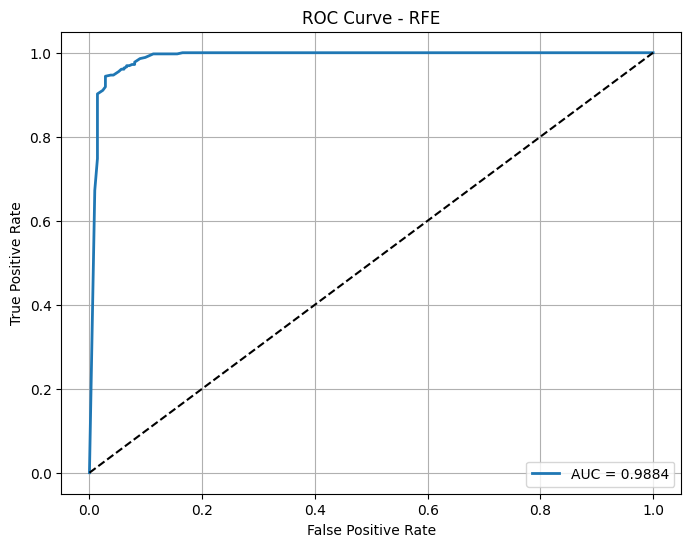

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
n_features = X.shape[1]

# Parameters
n_selected_features = 10  # Number of features to select via RFE
n_estimators = 50
max_depth = None
criterion = 'gini'
bootstrap = True
random_state = 0
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Start timer
start_time = time.time()

# Feature selector (RFE with Random Forest)
rfe_estimator = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    criterion=criterion,
    bootstrap=bootstrap,
    random_state=random_state
)
selector = RFE(rfe_estimator, n_features_to_select=n_selected_features)
selector.fit(X, y)
X_selected = selector.transform(X)
selected_indices = np.where(selector.support_)[0]

# Classification using K-Fold
all_preds, all_probs, all_true = [], [], []
model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    criterion=criterion,
    bootstrap=bootstrap,
    random_state=random_state
)

for train_idx, test_idx in kf.split(X_selected):
    X_train, X_test = X_selected[train_idx], X_selected[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    all_preds.extend(preds)
    all_probs.extend(probs)
    all_true.extend(y_test)

# End timer
end_time = time.time()
duration_minutes = (end_time - start_time) / 60

# Convert lists to arrays
all_true = np.array(all_true)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Metrics
acc = accuracy_score(all_true, all_preds)
bal_acc = balanced_accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds)
rec = recall_score(all_true, all_preds)
f1 = f1_score(all_true, all_preds)
auc = roc_auc_score(all_true, all_probs)
cm = confusion_matrix(all_true, all_preds)
report = classification_report(all_true, all_preds)

# Display results
print("\n=== RFE + Random Forest Results ===")
print(f"Selected Feature Indices: {selected_indices}")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Time: {duration_minutes:.2f} minutes")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RFE')
plt.legend()
plt.grid(True)
plt.show()
